# GO-3055: сводная обработка, калибровка и графики

Этот ноутбук **не повторяет измерение SBF** и не изменяет продукты `sbf-2.ipynb`. Он читает завершённый пакет `runs/sbf2_go3055`, присоединяет литературные расстояния TRGB, собирает единую таблицу, оценивает внутренний бюджет ошибок и строит графики для анализа и статьи.

Основной вариант сохраняет методику текущего Jensen/TRGB-SBF пайплайна: сигнал F150W, цвет F090W−F150W, два фиксированных круговых кольца и классическая модель спектра мощности. Все исключения из калибровки задаются явно в одной ячейке.

## 1. Настройки

Ячейки ниже только читают готовые результаты. Новые таблицы и рисунки сохраняются в `runs/sbf2_go3055/analysis`.

In [2]:
import sys
print(sys.executable)

/Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/astro_env/bin/python3


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.io import fits
from scipy.optimize import minimize

RNG_SEED = 3055
N_BOOTSTRAP = 2000
USE_COLOR_PROXY_IN_FIT = False
ANNOTATE_POINTS = True
MAKE_CONTACT_SHEET = False

# Доля неопределённости поправки на неразрешённые источники.
# Это рабочее допущение для анализа чувствительности, а не измеренный результат.
PR_FRACTIONAL_ERROR = 0.25

# Явные ручные исключения. По умолчанию никого не исключаем.
MANUAL_EXCLUSIONS = set()

pd.set_option('display.max_columns', 120)
pd.set_option('display.precision', 4)

mpl.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [3]:
def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'code' / 'sbf-2.ipynb').exists():
            return candidate.resolve()
    raise FileNotFoundError('Не найден корень проекта с code/sbf-2.ipynb')

PROJECT_ROOT = find_project_root()
CODE_DIR = PROJECT_ROOT / 'code'
RUN_DIR = PROJECT_ROOT / 'runs' / 'sbf2_go3055'
BATCH_DIR = RUN_DIR / 'batch'
ANALYSIS_DIR = RUN_DIR / 'analysis'
FIGURE_DIR = ANALYSIS_DIR / 'figures'
TABLE_DIR = ANALYSIS_DIR / 'tables'

RESULTS_CSV = BATCH_DIR / 'sbf2_batch_results.csv'
QC_CSV = BATCH_DIR / 'go3055_qc.csv'
DISTANCE_CSV = CODE_DIR / 'sbf2_batch_outputs' / 'literature_distance_moduli.csv'
CATALOG_CSV = PROJECT_ROOT / 'data' / 'galaxy_catalog_go3055_go7763.csv'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Корень проекта: {PROJECT_ROOT}')
print(f'Результаты:      {RESULTS_CSV}')
print(f'Таблицы:         {TABLE_DIR}')
print(f'Рисунки:         {FIGURE_DIR}')

Корень проекта: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF
Результаты:      /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/batch/sbf2_batch_results.csv
Таблицы:         /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/tables
Рисунки:         /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures


## 2. Загрузка и механическая проверка

Здесь проверяются 14 уникальных целей, успешный статус обработки и наличие семи заявленных артефактов. Если контракт нарушен, ноутбук останавливается до калибровки.

In [4]:
results = pd.read_csv(RESULTS_CSV)
qc = pd.read_csv(QC_CSV)
distances = pd.read_csv(DISTANCE_CSV)
catalog = pd.read_csv(CATALOG_CSV)

assert len(results) == 14, f'Ожидалось 14 целей, найдено {len(results)}'
assert results['galaxy'].is_unique, 'В итоговой таблице есть повторяющиеся галактики'
assert set(results['status']) == {'ok'}, results[['galaxy', 'status']]
assert results['artifacts_verified'].astype(str).str.lower().eq('true').all(), 'Не все артефакты проверены'
assert pd.to_numeric(results['artifact_count'], errors='coerce').eq(7).all(), 'Нарушен контракт семи артефактов'

artifact_columns = [
    'model_full_fits',
    'science_residual_fits',
    'science_residual_pre_catalog_fits',
    'science_residual_raw_fits',
    'inner_usable_residual_fits',
    'outer_usable_residual_fits',
    'annulus_summary_csv',
]
missing_artifacts = []
for row in results.itertuples(index=False):
    for column in artifact_columns:
        path = Path(getattr(row, column))
        if not path.exists():
            missing_artifacts.append((row.galaxy, column, str(path)))
assert not missing_artifacts, pd.DataFrame(missing_artifacts, columns=['galaxy', 'artifact', 'path'])

print('Механическая проверка пройдена: 14/14 целей, по 7/7 артефактов.')
display(results[['galaxy', 'signal_filter', 'color_filter', 'recommended_mbar_weighted',
                 'recommended_sigma_adopted', 'color_F090W_F150W', 'qc_status']])

Механическая проверка пройдена: 14/14 целей, по 7/7 артефактов.


,galaxy,signal_filter,color_filter,recommended_mbar_weighted,recommended_sigma_adopted,color_F090W_F150W,qc_status
0,NGC 1380,F150W,F090W,28.1197,0.0225,0.5217,review
1,NGC 1399,F150W,F090W,28.1863,0.0097,0.5782,review
2,NGC 1404,F150W,F090W,28.2123,0.0132,0.5671,review
3,NGC 1549,F150W,F090W,27.9892,0.0194,0.5415,review
4,NGC 3379,F150W,F090W,27.0610,0.0844,0.5739,review
5,NGC 4374,F150W,F090W,27.9854,0.0214,0.5937,review
6,NGC 4406,F150W,F090W,27.8785,0.0308,0.6367,review
7,NGC 4472,F150W,F090W,27.7748,0.0224,0.6401,review
8,NGC 4486,F150W,F090W,27.8925,0.0292,0.6684,review
9,NGC 4552,F150W,F090W,27.8968,0.0429,0.5981,review


## 3. Единая таблица измерений

Литературный модуль расстояния используется как внешний TRGB-якорь. Абсолютная флуктуационная звёздная величина определяется как

$$\overline{M}_{150}=\overline{m}_{150}-\mu_{\rm TRGB}.$$

Отрицательный $P_1$ отмечается отдельно, но не используется как автоматический повод удалить объект: этот флаг присутствует у всей текущей выборки и относится к поведению фонового члена аппроксимации.

In [5]:
qc_extra_columns = [
    'galaxy', 'annulus_delta_mag', 'annulus_delta_z',
    'inner_mbar', 'inner_mbar_sigma', 'inner_P1', 'inner_usable_fraction',
    'inner_Pr_over_P0', 'inner_psf_scatter_mag',
    'outer_mbar', 'outer_mbar_sigma', 'outer_P1', 'outer_usable_fraction',
    'outer_Pr_over_P0', 'outer_psf_scatter_mag',
]
catalog_columns = [
    'galaxy', 'ra_deg_icrs', 'dec_deg_icrs', 'cluster_or_group',
    'distance_mpc', 'distance_stat_uncertainty_mpc', 'distance_method',
]
distance_columns = [
    'galaxy', 'mu_lit', 'sigma_mu_lit', 'distance_lit_mpc',
    'sigma_distance_lit_mpc', 'distance_method', 'distance_reference',
]

master = (
    results
    .merge(qc[qc_extra_columns], on='galaxy', how='left', validate='one_to_one')
    .merge(distances[distance_columns], on='galaxy', how='left', validate='one_to_one', suffixes=('', '_trgb'))
    .merge(catalog[catalog_columns], on='galaxy', how='left', validate='one_to_one', suffixes=('', '_catalog'))
)

numeric_columns = [
    'recommended_mbar_weighted', 'recommended_sigma_adopted',
    'color_F090W_F150W', 'color_sigma_proxy', 'mu_lit', 'sigma_mu_lit',
    'annulus_delta_mag', 'annulus_delta_z', 'inner_mbar', 'outer_mbar',
    'inner_mbar_sigma', 'outer_mbar_sigma', 'inner_P1', 'outer_P1',
    'inner_usable_fraction', 'outer_usable_fraction',
    'inner_model_coverage', 'outer_model_coverage',
    'inner_Pr_over_P0', 'outer_Pr_over_P0',
    'inner_psf_scatter_mag', 'outer_psf_scatter_mag',
]
for column in numeric_columns:
    master[column] = pd.to_numeric(master[column], errors='coerce')

cluster_text = master['cluster_or_group'].fillna('').str.lower()
master['environment'] = np.select(
    [cluster_text.str.contains('fornax'), cluster_text.str.contains('virgo')],
    ['Fornax', 'Virgo'],
    default='Other',
)
master['mbar_F150W'] = master['recommended_mbar_weighted']
master['color_F090W_F150W'] = master['color_F090W_F150W']
master['Mbar_F150W'] = master['mbar_F150W'] - master['mu_lit']

master['coverage_warning'] = (
    (master['inner_usable_fraction'] < 0.70)
    | (master['outer_usable_fraction'] < 0.70)
    | (master['inner_model_coverage'] < 0.90)
    | (master['outer_model_coverage'] < 0.90)
)
master['annulus_warning'] = (
    (master['annulus_delta_mag'].abs() > 0.10)
    | (master['annulus_delta_z'].abs() > 3.0)
)
master['structural_warning'] = master['coverage_warning'] | master['annulus_warning']
master['P1_nonpositive'] = (master['inner_P1'] <= 0) | (master['outer_P1'] <= 0)
master['manual_exclusion'] = master['galaxy'].isin(MANUAL_EXCLUSIONS)

required_for_fit = ['mbar_F150W', 'color_F090W_F150W', 'mu_lit', 'sigma_mu_lit']
master['include_main'] = master[required_for_fit].notna().all(axis=1) & ~master['manual_exclusion']
master['include_structural_clean'] = master['include_main'] & ~master['structural_warning']

assert master['mu_lit'].notna().all(), 'Не для всех целей найден TRGB-модуль расстояния'
display(master[['galaxy', 'environment', 'mbar_F150W', 'color_F090W_F150W',
                'mu_lit', 'Mbar_F150W', 'structural_warning', 'P1_nonpositive']])

,galaxy,environment,mbar_F150W,color_F090W_F150W,mu_lit,Mbar_F150W,structural_warning,P1_nonpositive
0,NGC 1380,Fornax,28.1197,0.5217,31.408,-3.2883,True,True
1,NGC 1399,Fornax,28.1863,0.5782,31.498,-3.3117,False,True
2,NGC 1404,Fornax,28.2123,0.5671,31.366,-3.1537,False,True
3,NGC 1549,Other,27.9892,0.5415,31.231,-3.2418,False,True
4,NGC 3379,Other,27.0610,0.5739,30.078,-3.0170,True,True
5,NGC 4374,Virgo,27.9854,0.5937,31.112,-3.1266,False,True
6,NGC 4406,Virgo,27.8785,0.6367,31.096,-3.2175,False,True
7,NGC 4472,Virgo,27.7748,0.6401,31.016,-3.2412,False,True
8,NGC 4486,Virgo,27.8925,0.6684,31.046,-3.1535,False,True
9,NGC 4552,Virgo,27.8968,0.5981,30.923,-3.0262,True,True


## 4. Внутренний бюджет ошибок

Текущая `recommended_sigma_adopted` уже включает формальную ошибку двух колец и их расхождение. Ниже к ней отдельно добавляются разброс по PSF и рабочая оценка неопределённости $P_r$ — вклада неразрешённых источников.

Это пока **внутренний**, а не окончательный бюджет: неопределённости неба и галактического поглощения в batch не измерены и намеренно оставлены `NaN`, чтобы они не исчезли под неявными нулями. Общая систематика нуль-пункта TRGB 0.046 mag также хранится отдельно и не добавляется независимо к каждой галактике.

In [6]:
TRGB_COMMON_ZEROPOINT_MAG = 0.046

def annulus_weights(row):
    si = max(float(row['inner_mbar_sigma']), 1e-6)
    so = max(float(row['outer_mbar_sigma']), 1e-6)
    wi, wo = 1.0 / si**2, 1.0 / so**2
    return wi / (wi + wo), wo / (wi + wo)

def combine_independent_component(row, inner_column, outer_column):
    wi, wo = annulus_weights(row)
    inner = float(row[inner_column]) if np.isfinite(row[inner_column]) else 0.0
    outer = float(row[outer_column]) if np.isfinite(row[outer_column]) else 0.0
    return np.hypot(wi * inner, wo * outer)

def pr_magnitude_uncertainty(pr_over_p0):
    r = float(pr_over_p0)
    if not np.isfinite(r) or r < 0 or r >= 0.95:
        return np.nan
    return 1.085736 * PR_FRACTIONAL_ERROR * r / (1.0 - r)

master['sigma_measurement_mag'] = master['recommended_sigma_adopted']
master['sigma_psf_mag'] = master.apply(
    combine_independent_component,
    axis=1,
    args=('inner_psf_scatter_mag', 'outer_psf_scatter_mag'),
)
master['inner_sigma_Pr_mag'] = master['inner_Pr_over_P0'].map(pr_magnitude_uncertainty)
master['outer_sigma_Pr_mag'] = master['outer_Pr_over_P0'].map(pr_magnitude_uncertainty)
master['sigma_Pr_mag'] = master.apply(
    combine_independent_component,
    axis=1,
    args=('inner_sigma_Pr_mag', 'outer_sigma_Pr_mag'),
)

master['sigma_sky_mag'] = np.nan
master['sigma_extinction_mag'] = np.nan
master['sigma_mbar_internal'] = np.sqrt(
    master['sigma_measurement_mag']**2
    + master['sigma_psf_mag']**2
    + master['sigma_Pr_mag']**2
)
master['sigma_mbar_total'] = np.where(
    master[['sigma_sky_mag', 'sigma_extinction_mag']].notna().all(axis=1),
    np.sqrt(
        master['sigma_mbar_internal']**2
        + master['sigma_sky_mag']**2
        + master['sigma_extinction_mag']**2
    ),
    np.nan,
)
master['sigma_Mbar_internal'] = np.hypot(master['sigma_mbar_internal'], master['sigma_mu_lit'])

display(master[['galaxy', 'sigma_measurement_mag', 'sigma_psf_mag', 'sigma_Pr_mag',
                'sigma_mbar_internal', 'sigma_mu_lit', 'sigma_Mbar_internal']])

,galaxy,sigma_measurement_mag,sigma_psf_mag,sigma_Pr_mag,sigma_mbar_internal,sigma_mu_lit,sigma_Mbar_internal
0,NGC 1380,0.0225,0.0010,4.6604e-06,0.0225,0.025,0.0336
1,NGC 1399,0.0097,0.0021,6.0577e-04,0.0099,0.026,0.0278
2,NGC 1404,0.0132,0.0010,9.7585e-04,0.0133,0.025,0.0283
3,NGC 1549,0.0194,0.0028,2.2017e-04,0.0196,0.026,0.0326
4,NGC 3379,0.0844,0.0015,1.3837e-03,0.0844,0.028,0.0889
5,NGC 4374,0.0214,0.0022,1.1448e-03,0.0216,0.027,0.0346
6,NGC 4406,0.0308,0.0025,9.4615e-04,0.0309,0.025,0.0398
7,NGC 4472,0.0224,0.0008,3.7626e-05,0.0224,0.027,0.0351
8,NGC 4486,0.0292,0.0014,1.5376e-04,0.0292,0.025,0.0385
9,NGC 4552,0.0429,0.0016,1.0231e-03,0.0429,0.028,0.0513


## 5. Прокси светимости

Для раскраски точек интегрируется гладкая F150W-модель внутри фиксированной апертуры 32.8 arcsec. Это **не полная светимость галактики**, а воспроизводимый апертурный прокси, пригодный для поиска зависимости остатков от светимости.

In [7]:
LUMINOSITY_APERTURE_ARCSEC = 32.8

def model_aperture_magnitude(row, radius_arcsec=LUMINOSITY_APERTURE_ARCSEC):
    path = Path(row['model_full_fits'])
    pixel_scale = float(row['science_pixel_scale_arcsec'])
    radius_px = radius_arcsec / pixel_scale

    with fits.open(path, memmap=True) as hdul:
        hdu = hdul[0]
        ny, nx = hdu.data.shape
        x0 = float(hdu.header.get('SBFXCEN', (nx - 1) / 2))
        y0 = float(hdu.header.get('SBFYCEN', (ny - 1) / 2))
        half = int(np.ceil(radius_px)) + 2
        x1, x2 = max(0, int(x0) - half), min(nx, int(x0) + half + 1)
        y1, y2 = max(0, int(y0) - half), min(ny, int(y0) + half + 1)
        image = np.asarray(hdu.data[y1:y2, x1:x2], dtype=float)
        yy, xx = np.ogrid[y1:y2, x1:x2]
        aperture = (xx - x0)**2 + (yy - y0)**2 <= radius_px**2
        model_sum_mjy_sr = np.nansum(image[aperture])
        pixel_area_sr = float(hdu.header.get('PIXAR_SR', (pixel_scale / 206265.0)**2))

    flux_jy = model_sum_mjy_sr * 1e6 * pixel_area_sr
    if not np.isfinite(flux_jy) or flux_jy <= 0:
        return np.nan
    return -2.5 * np.log10(flux_jy / 3631.0)

master['m150_model_aperture'] = master.apply(model_aperture_magnitude, axis=1)
master['M150_model_aperture'] = master['m150_model_aperture'] - master['mu_lit']

display(master[['galaxy', 'environment', 'm150_model_aperture', 'M150_model_aperture']])

,galaxy,environment,m150_model_aperture,M150_model_aperture
0,NGC 1380,Fornax,9.1849,-22.2231
1,NGC 1399,Fornax,8.7920,-22.7060
2,NGC 1404,Fornax,8.8840,-22.4820
3,NGC 1549,Other,9.1212,-22.1098
4,NGC 3379,Other,8.6636,-21.4144
5,NGC 4374,Virgo,8.6948,-22.4172
6,NGC 4406,Virgo,8.9547,-22.1413
7,NGC 4472,Virgo,8.2343,-22.7817
8,NGC 4486,Virgo,8.5063,-22.5397
9,NGC 4552,Virgo,8.9772,-21.9458


## 6. Сохранение основной таблицы

CSV содержит как исходные измерения, так и все принятые здесь флаги и компоненты ошибки. Именно эту таблицу следует считать источником данных для дальнейших графиков.

In [8]:
master_path = TABLE_DIR / 'go3055_master_measurements.csv'
error_path = TABLE_DIR / 'go3055_error_budget.csv'
calibration_path = TABLE_DIR / 'go3055_calibration_table.csv'

master.sort_values('galaxy').to_csv(master_path, index=False)

error_columns = [
    'galaxy', 'sigma_measurement_mag', 'sigma_psf_mag', 'sigma_Pr_mag',
    'sigma_sky_mag', 'sigma_extinction_mag', 'sigma_mbar_internal',
    'sigma_mbar_total', 'sigma_mu_lit', 'sigma_Mbar_internal',
]
master[error_columns].sort_values('galaxy').to_csv(error_path, index=False)

calibration_columns = [
    'galaxy', 'ra_deg_icrs', 'dec_deg_icrs', 'environment', 'cluster_or_group',
    'mbar_F150W', 'sigma_mbar_internal', 'color_F090W_F150W', 'color_sigma_proxy',
    'mu_lit', 'sigma_mu_lit', 'Mbar_F150W', 'sigma_Mbar_internal',
    'M150_model_aperture', 'annulus_delta_mag', 'structural_warning',
    'P1_nonpositive', 'include_main', 'include_structural_clean',
]
paper_table = master[calibration_columns].sort_values('galaxy')
paper_table.to_csv(calibration_path, index=False)
paper_table.to_latex(
    TABLE_DIR / 'go3055_calibration_table.tex',
    index=False,
    float_format='%.3f',
)

print(f'Сохранено: {master_path}')
print(f'Сохранено: {error_path}')
print(f'Сохранено: {calibration_path}')

Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/tables/go3055_master_measurements.csv
Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/tables/go3055_error_budget.csv
Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/tables/go3055_calibration_table.csv


## 7. Линейная калибровка

Модель:

$$\overline{M}_{150}=a+b\left[(F090W-F150W)-C_0\right],$$

с дополнительным внутренним разбросом $\sigma_{\rm int}$. По умолчанию `color_sigma_proxy` не считается формальной ошибкой цвета и не входит в правдоподобие. Его влияние можно отдельно проверить переключателем `USE_COLOR_PROXY_IN_FIT`.

In [9]:
def fit_calibration(frame, use_color_errors=USE_COLOR_PROXY_IN_FIT, color_center=None):
    data = frame.dropna(subset=['color_F090W_F150W', 'Mbar_F150W', 'sigma_Mbar_internal']).copy()
    if len(data) < 4 or data['color_F090W_F150W'].nunique() < 2:
        raise ValueError('Для калибровки недостаточно независимых точек')

    x = data['color_F090W_F150W'].to_numpy(float)
    y = data['Mbar_F150W'].to_numpy(float)
    sy = data['sigma_Mbar_internal'].to_numpy(float)
    sx = data['color_sigma_proxy'].fillna(0).to_numpy(float) if use_color_errors else np.zeros(len(data))
    x0 = float(np.nanmedian(x) if color_center is None else color_center)
    slope0, intercept0 = np.polyfit(x - x0, y, 1)

    def negative_log_likelihood(theta):
        intercept, slope, log_sigma_int = theta
        sigma_int = np.exp(log_sigma_int)
        model = intercept + slope * (x - x0)
        variance = sy**2 + (slope * sx)**2 + sigma_int**2
        return 0.5 * np.sum(np.log(2 * np.pi * variance) + (y - model)**2 / variance)

    solution = minimize(
        negative_log_likelihood,
        x0=[intercept0, slope0, np.log(0.05)],
        method='L-BFGS-B',
        bounds=[(None, None), (None, None), (np.log(1e-5), np.log(1.0))],
    )
    if not solution.success:
        raise RuntimeError(solution.message)

    intercept, slope, log_sigma_int = solution.x
    k = 3
    n = len(data)
    aic = 2 * k + 2 * solution.fun
    aicc = aic + 2 * k * (k + 1) / (n - k - 1) if n > k + 1 else np.inf
    return {
        'n': n,
        'color_center': x0,
        'intercept': float(intercept),
        'slope': float(slope),
        'sigma_int': float(np.exp(log_sigma_int)),
        'log_likelihood': float(-solution.fun),
        'aic': float(aic),
        'aicc': float(aicc),
        'use_color_errors': bool(use_color_errors),
    }

def bootstrap_calibration(frame, n_bootstrap=N_BOOTSTRAP, seed=RNG_SEED, color_center=None):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_bootstrap):
        sample = frame.iloc[rng.integers(0, len(frame), len(frame))]
        if sample['color_F090W_F150W'].nunique() < 2:
            continue
        try:
            rows.append(fit_calibration(sample, color_center=color_center))
        except (ValueError, RuntimeError, np.linalg.LinAlgError):
            continue
    return pd.DataFrame(rows)

sample_all = master.loc[master['include_main']].copy()
sample_clean = master.loc[master['include_structural_clean']].copy()
common_color_center = float(sample_all['color_F090W_F150W'].median())

fit_all = fit_calibration(sample_all, color_center=common_color_center)
fit_clean = fit_calibration(sample_clean, color_center=common_color_center)
boot_all = bootstrap_calibration(sample_all, color_center=common_color_center)
boot_clean = bootstrap_calibration(sample_clean, seed=RNG_SEED + 1, color_center=common_color_center)

def summarize_fit(name, fit, bootstrap):
    row = {'sample': name, **fit, 'bootstrap_success': len(bootstrap)}
    for parameter in ['intercept', 'slope', 'sigma_int']:
        row[f'{parameter}_p16'] = bootstrap[parameter].quantile(0.16)
        row[f'{parameter}_p50'] = bootstrap[parameter].quantile(0.50)
        row[f'{parameter}_p84'] = bootstrap[parameter].quantile(0.84)
    return row

fit_summary = pd.DataFrame([
    summarize_fit('all', fit_all, boot_all),
    summarize_fit('structural_clean', fit_clean, boot_clean),
])
fit_summary.to_csv(TABLE_DIR / 'go3055_fit_summary.csv', index=False)
display(fit_summary)

,sample,n,color_center,intercept,slope,sigma_int,log_likelihood,aic,aicc,use_color_errors,bootstrap_success,intercept_p16,intercept_p50,intercept_p84,slope_p16,slope_p50,slope_p84,sigma_int_p16,sigma_int_p50,sigma_int_p84
0,all,14,0.5908,-3.1696,0.7136,0.0716,14.4830,-22.9660,-20.5660,False,2000,-3.1894,-3.1670,-3.1430,0.2368,0.6852,1.1621,0.0500,0.0651,0.0776
1,structural_clean,9,0.5908,-3.1879,0.3643,0.0620,11.0618,-16.1236,-11.3236,False,2000,-3.2136,-3.1839,-3.1578,-0.1928,0.3693,0.8504,0.0325,0.0545,0.0671


## 8. Главная калибровочная диаграмма

Форма маркера отделяет Virgo, Fornax и остальные окружения. Цвет точки показывает апертурный прокси светимости. Сплошная линия — вся выборка, пунктир — вариант без объектов со структурными предупреждениями. Это сравнение чувствительности, а не скрытая выбраковка.

Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures/go3055_f150w_sbf_calibration.png


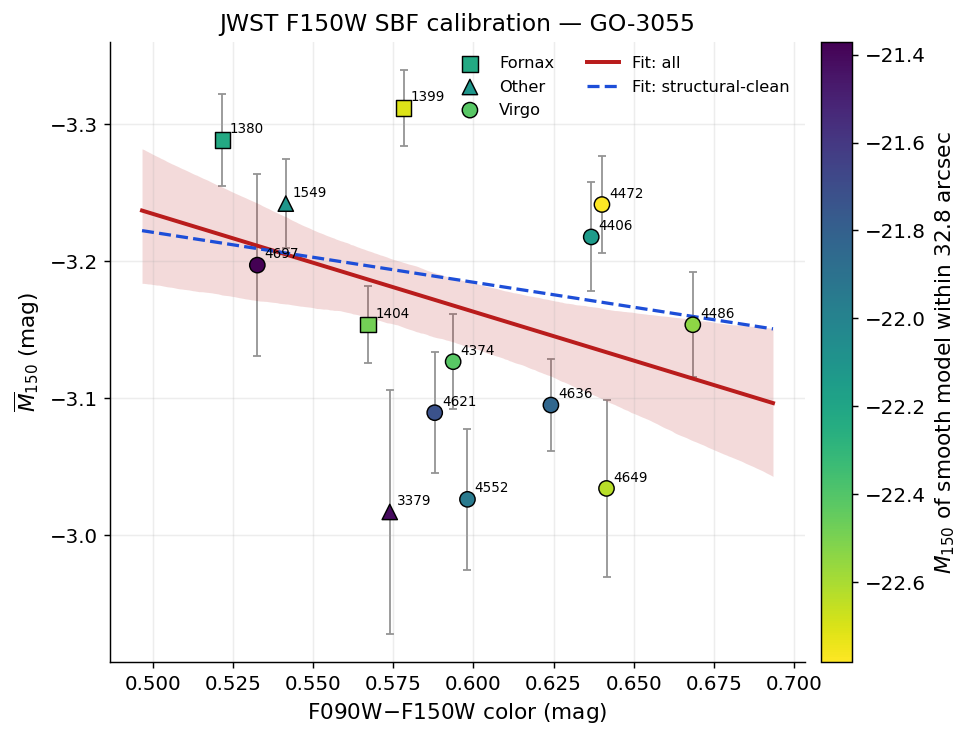

In [10]:
ENVIRONMENT_STYLE = {
    'Virgo': {'marker': 'o', 'label': 'Virgo'},
    'Fornax': {'marker': 's', 'label': 'Fornax'},
    'Other': {'marker': '^', 'label': 'Other'},
}

def save_figure(fig, stem):
    png = FIGURE_DIR / f'{stem}.png'
    pdf = FIGURE_DIR / f'{stem}.pdf'
    fig.savefig(png, bbox_inches='tight', facecolor='white')
    fig.savefig(pdf, bbox_inches='tight', facecolor='white')
    print(f'Сохранено: {png}')
    return png, pdf

fig, ax = plt.subplots(figsize=(8.3, 6.2))
luminosity_values = sample_all['M150_model_aperture'].to_numpy(float)
normalizer = mpl.colors.Normalize(np.nanmin(luminosity_values), np.nanmax(luminosity_values))
cmap = mpl.colormaps['viridis_r']

for environment, group in sample_all.groupby('environment', sort=False):
    style = ENVIRONMENT_STYLE[environment]
    ax.errorbar(
        group['color_F090W_F150W'], group['Mbar_F150W'],
        xerr=group['color_sigma_proxy'] if USE_COLOR_PROXY_IN_FIT else None,
        yerr=group['sigma_Mbar_internal'], fmt='none', ecolor='0.58',
        elinewidth=1.0, capsize=2, zorder=1,
    )
    ax.scatter(
        group['color_F090W_F150W'], group['Mbar_F150W'],
        c=group['M150_model_aperture'], cmap=cmap, norm=normalizer,
        marker=style['marker'], s=72, edgecolor='black', linewidth=0.8,
        label=style['label'], zorder=3,
    )

x_grid = np.linspace(sample_all['color_F090W_F150W'].min() - 0.025,
                     sample_all['color_F090W_F150W'].max() + 0.025, 300)
y_all = fit_all['intercept'] + fit_all['slope'] * (x_grid - common_color_center)
ax.plot(x_grid, y_all, color='#b91c1c', lw=2.2, label='Fit: all')

if len(boot_all):
    predictions = (
        boot_all['intercept'].to_numpy()[:, None]
        + boot_all['slope'].to_numpy()[:, None] * (x_grid[None, :] - common_color_center)
    )
    low, high = np.nanpercentile(predictions, [16, 84], axis=0)
    ax.fill_between(x_grid, low, high, color='#b91c1c', alpha=0.16, linewidth=0)

y_clean = fit_clean['intercept'] + fit_clean['slope'] * (x_grid - common_color_center)
ax.plot(x_grid, y_clean, color='#1d4ed8', lw=1.8, ls='--', label='Fit: structural-clean')

if ANNOTATE_POINTS:
    for row in sample_all.itertuples():
        ax.annotate(row.galaxy.replace('NGC ', ''),
                    (row.color_F090W_F150W, row.Mbar_F150W),
                    xytext=(4, 4), textcoords='offset points', fontsize=7.5)

colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=normalizer, cmap=cmap), ax=ax, pad=0.02)
colorbar.set_label(r'$M_{150}$ of smooth model within 32.8 arcsec')
ax.set_xlabel(r'F090W$-$F150W color (mag)')
ax.set_ylabel(r'$\overline{M}_{150}$ (mag)')
ax.set_title('JWST F150W SBF calibration — GO-3055')
ax.invert_yaxis()
ax.legend(ncol=2, frameon=False)
save_figure(fig, 'go3055_f150w_sbf_calibration')
plt.show()

## 9. Проверка расстояний без подгонки объекта по самому себе

Для каждой галактики калибровка строится по остальным 13 объектам, после чего вычисляется $\mu_{\rm SBF}$. Такая leave-one-out проверка честнее обычного сравнения на той же выборке, хотя всё ещё не заменяет полностью независимую внешнюю калибровку.

Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures/go3055_sbf_vs_trgb_leave_one_out.png


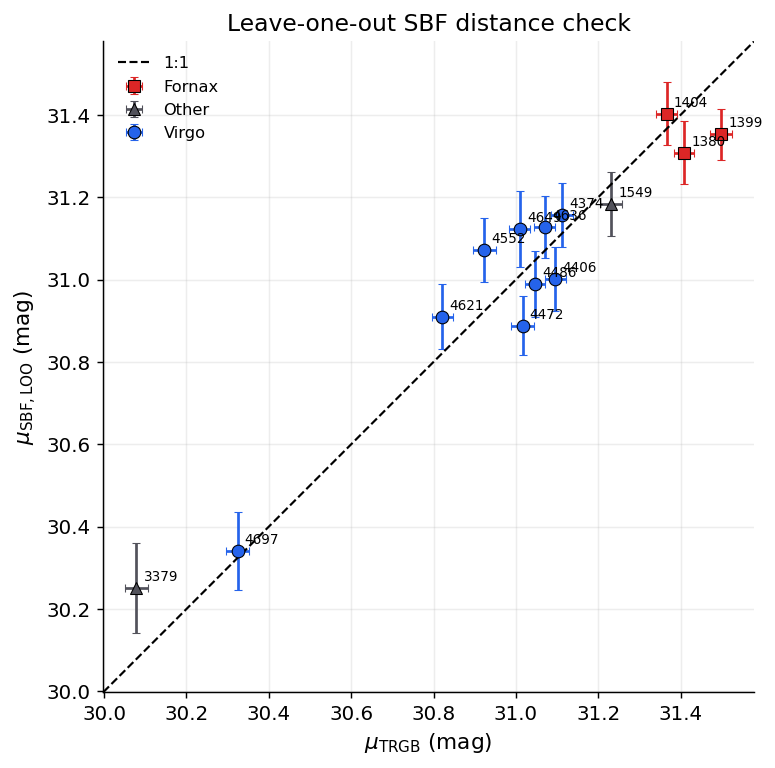

,galaxy,environment,mu_trgb,sigma_mu_trgb,mu_sbf_loo,sigma_mu_sbf_internal,delta_mu_sbf_minus_trgb,predicted_Mbar_loo
4,NGC 3379,Other,30.078,0.028,30.2510,0.1088,0.1730,-3.1900
9,NGC 4552,Virgo,30.923,0.028,31.0720,0.0776,0.1490,-3.1752
1,NGC 1399,Fornax,31.498,0.026,31.3526,0.0620,-0.1454,-3.1662
7,NGC 4472,Virgo,31.016,0.027,30.8879,0.0713,-0.1281,-3.1131
12,NGC 4649,Virgo,31.009,0.025,31.1219,0.0925,0.1129,-3.1471
0,NGC 1380,Fornax,31.408,0.025,31.3084,0.0757,-0.0996,-3.1887
6,NGC 4406,Virgo,31.096,0.025,31.0011,0.0782,-0.0949,-3.1226
10,NGC 4621,Virgo,30.821,0.026,30.9098,0.0792,0.0888,-3.1782
11,NGC 4636,Virgo,31.070,0.026,31.1275,0.0763,0.0575,-3.1525
8,NGC 4486,Virgo,31.046,0.025,30.9890,0.0802,-0.0570,-3.0965


In [11]:
def leave_one_out_distances(frame):
    rows = []
    for index, target in frame.iterrows():
        training = frame.drop(index=index)
        fit = fit_calibration(training, color_center=common_color_center)
        predicted_Mbar = fit['intercept'] + fit['slope'] * (
            target['color_F090W_F150W'] - common_color_center
        )
        mu_sbf = target['mbar_F150W'] - predicted_Mbar
        sigma_mu_sbf_internal = np.hypot(target['sigma_mbar_internal'], fit['sigma_int'])
        rows.append({
            'galaxy': target['galaxy'],
            'environment': target['environment'],
            'mu_trgb': target['mu_lit'],
            'sigma_mu_trgb': target['sigma_mu_lit'],
            'mu_sbf_loo': mu_sbf,
            'sigma_mu_sbf_internal': sigma_mu_sbf_internal,
            'delta_mu_sbf_minus_trgb': mu_sbf - target['mu_lit'],
            'predicted_Mbar_loo': predicted_Mbar,
        })
    return pd.DataFrame(rows)

loo = leave_one_out_distances(sample_all)
loo.to_csv(TABLE_DIR / 'go3055_leave_one_out_distances.csv', index=False)

fig, ax = plt.subplots(figsize=(7.2, 6.5))
environment_colors = {'Virgo': '#2563eb', 'Fornax': '#dc2626', 'Other': '#52525b'}
for environment, group in loo.groupby('environment', sort=False):
    style = ENVIRONMENT_STYLE[environment]
    ax.errorbar(
        group['mu_trgb'], group['mu_sbf_loo'],
        xerr=group['sigma_mu_trgb'], yerr=group['sigma_mu_sbf_internal'],
        fmt=style['marker'], ms=7, color=environment_colors[environment],
        mec='black', mew=0.6, capsize=2, label=style['label'],
    )
for row in loo.itertuples():
    ax.annotate(row.galaxy.replace('NGC ', ''), (row.mu_trgb, row.mu_sbf_loo),
                xytext=(4, 4), textcoords='offset points', fontsize=7.5)

limits = [min(loo['mu_trgb'].min(), loo['mu_sbf_loo'].min()) - 0.08,
          max(loo['mu_trgb'].max(), loo['mu_sbf_loo'].max()) + 0.08]
ax.plot(limits, limits, color='black', lw=1.2, ls='--', label='1:1')
ax.set(xlim=limits, ylim=limits, xlabel=r'$\mu_{\rm TRGB}$ (mag)',
       ylabel=r'$\mu_{\rm SBF,LOO}$ (mag)', title='Leave-one-out SBF distance check')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False)
save_figure(fig, 'go3055_sbf_vs_trgb_leave_one_out')
plt.show()

display(loo.sort_values('delta_mu_sbf_minus_trgb', key=np.abs, ascending=False))

## 10. Кольца и остатки калибровки

Первая панель проверяет согласие внутренних и внешних колец. Вторая показывает остатки leave-one-out расстояний; именно здесь хорошо видны отдельные выбросы и возможные различия окружений.

Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures/go3055_annuli_and_distance_residuals.png


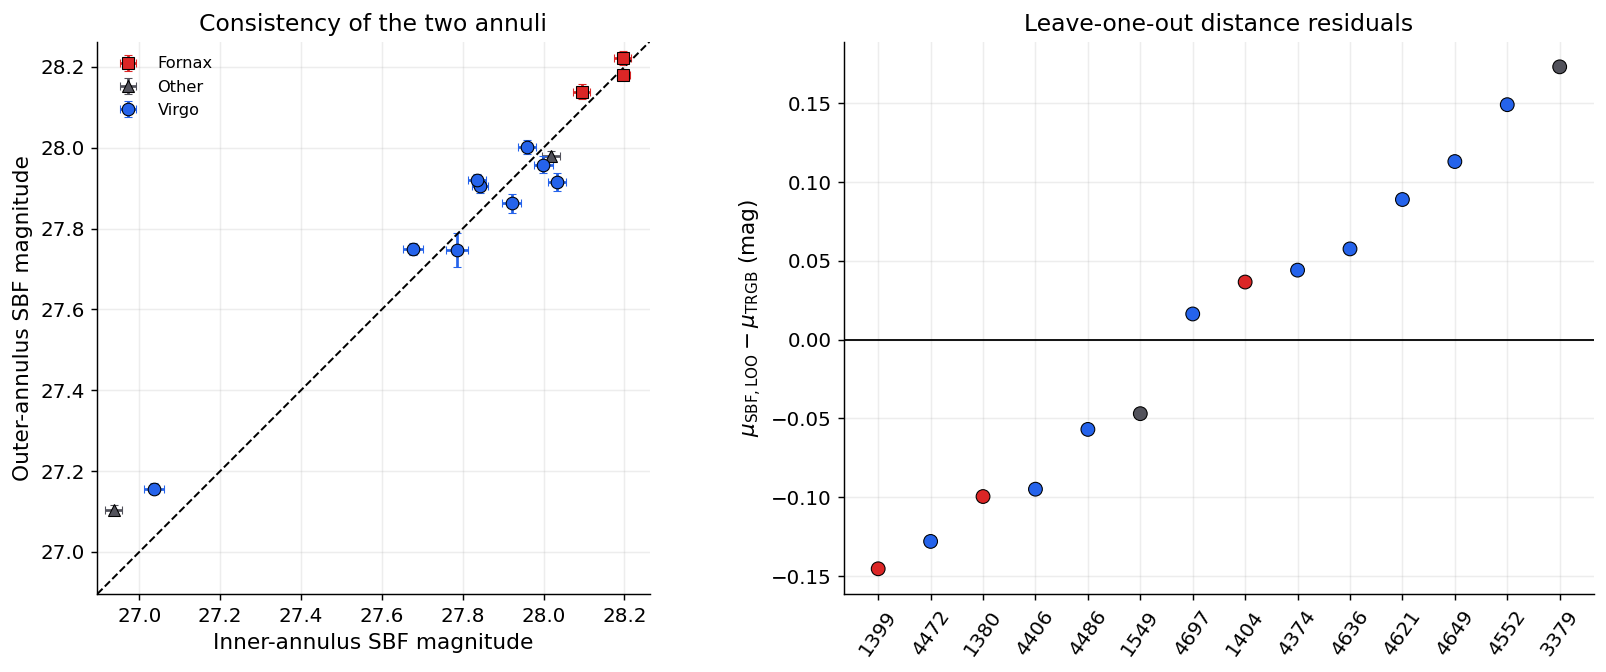

In [12]:
diagnostic = master.merge(loo[['galaxy', 'delta_mu_sbf_minus_trgb']], on='galaxy', how='left')
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.3))

ax = axes[0]
for environment, group in diagnostic.groupby('environment', sort=False):
    ax.errorbar(
        group['inner_mbar'], group['outer_mbar'],
        xerr=group['inner_mbar_sigma'], yerr=group['outer_mbar_sigma'],
        fmt=ENVIRONMENT_STYLE[environment]['marker'], ms=7,
        color=environment_colors[environment], mec='black', mew=0.6,
        capsize=2, label=environment,
    )
limits = [min(diagnostic['inner_mbar'].min(), diagnostic['outer_mbar'].min()) - 0.04,
          max(diagnostic['inner_mbar'].max(), diagnostic['outer_mbar'].max()) + 0.04]
ax.plot(limits, limits, color='black', lw=1.1, ls='--')
ax.set(xlim=limits, ylim=limits, xlabel='Inner-annulus SBF magnitude',
       ylabel='Outer-annulus SBF magnitude', title='Consistency of the two annuli')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False)

ax = axes[1]
ordered = diagnostic.sort_values('delta_mu_sbf_minus_trgb')
colors = ordered['environment'].map(environment_colors)
ax.axhline(0, color='black', lw=1.0)
ax.scatter(np.arange(len(ordered)), ordered['delta_mu_sbf_minus_trgb'],
           c=colors, s=58, edgecolor='black', linewidth=0.6, zorder=3)
ax.set_xticks(np.arange(len(ordered)), ordered['galaxy'].str.replace('NGC ', ''), rotation=55)
ax.set_ylabel(r'$\mu_{\rm SBF,LOO}-\mu_{\rm TRGB}$ (mag)')
ax.set_title('Leave-one-out distance residuals')

fig.tight_layout()
save_figure(fig, 'go3055_annuli_and_distance_residuals')
plt.show()

## 11. Диагностика качества и бюджета ошибок

Эти графики предназначены прежде всего для технического приложения: покрытие модели и рабочей маски, разность колец, значения фонового коэффициента $P_1$ и вклад отдельных компонентов во внутреннюю ошибку.

Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures/go3055_measurement_diagnostics.png


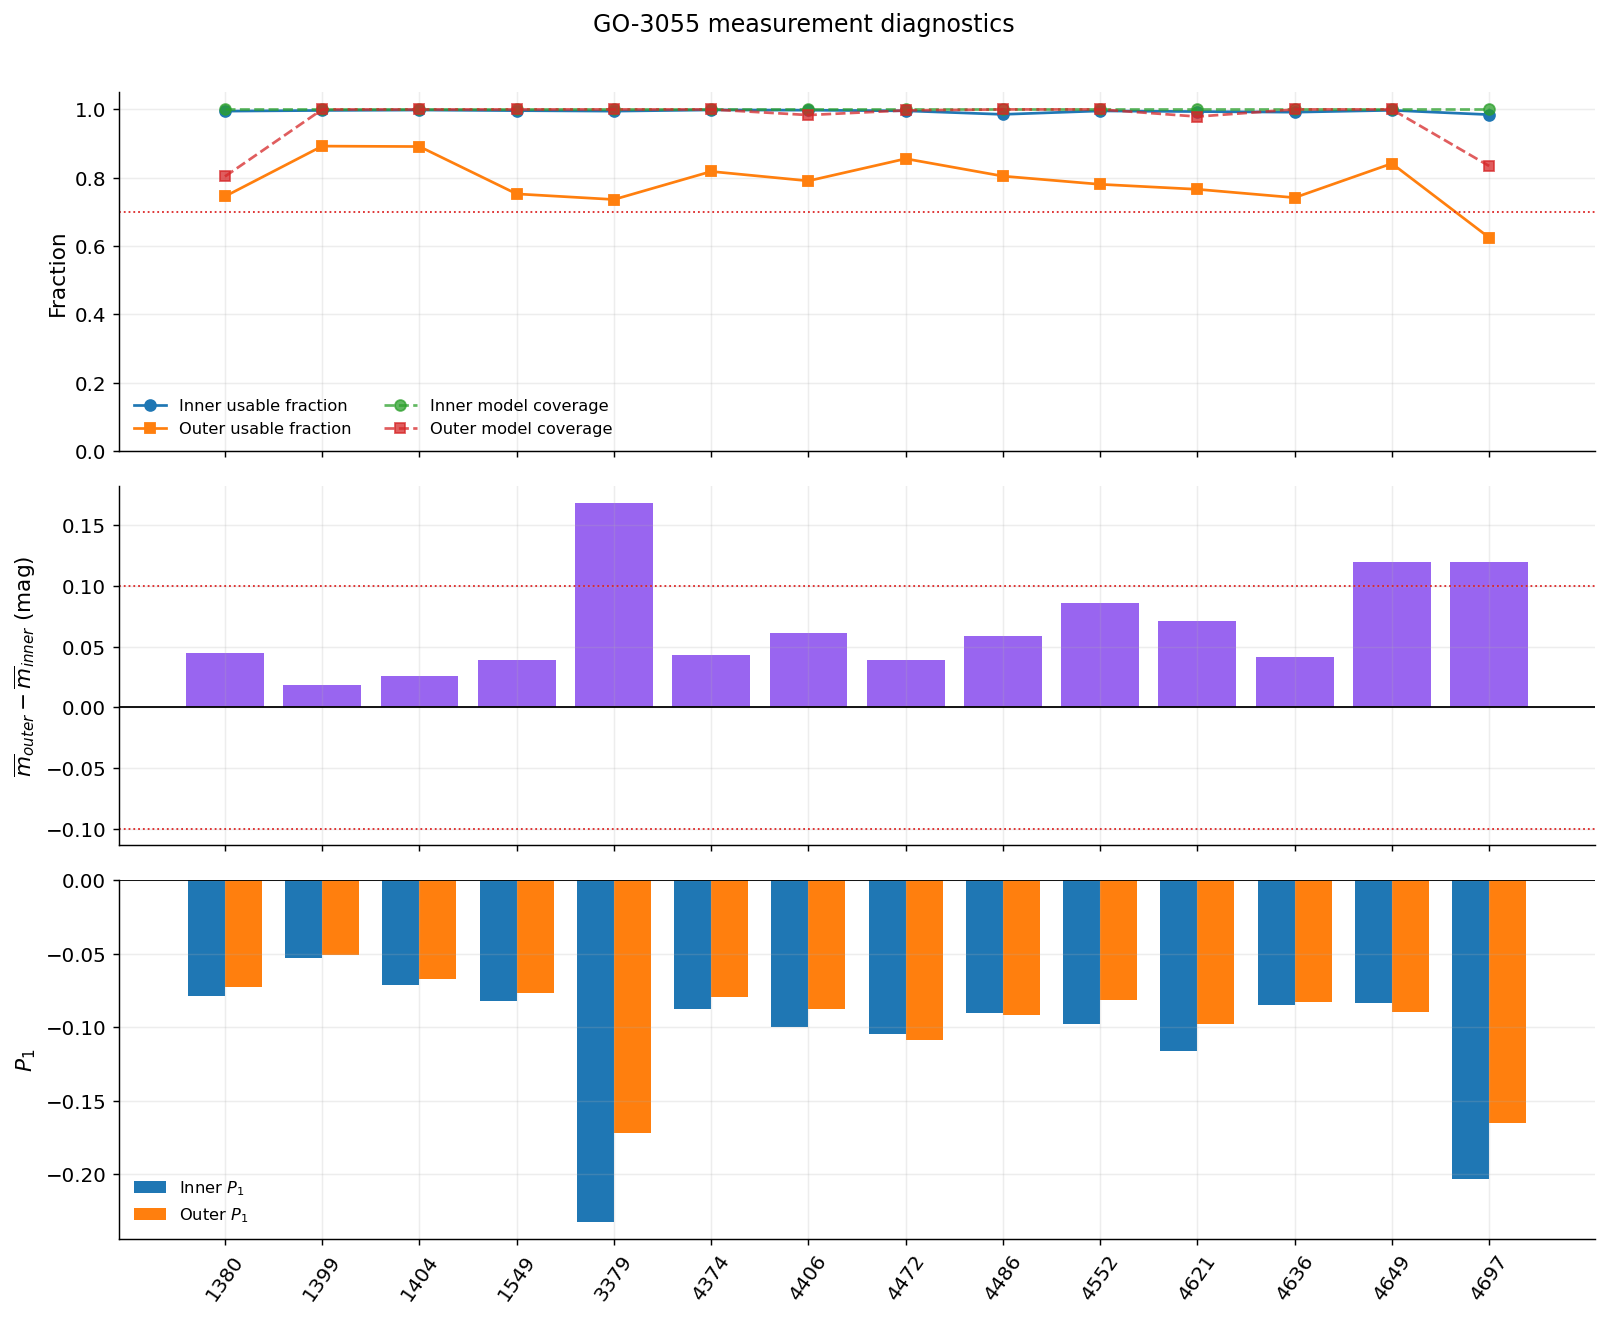

Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures/go3055_internal_error_budget.png


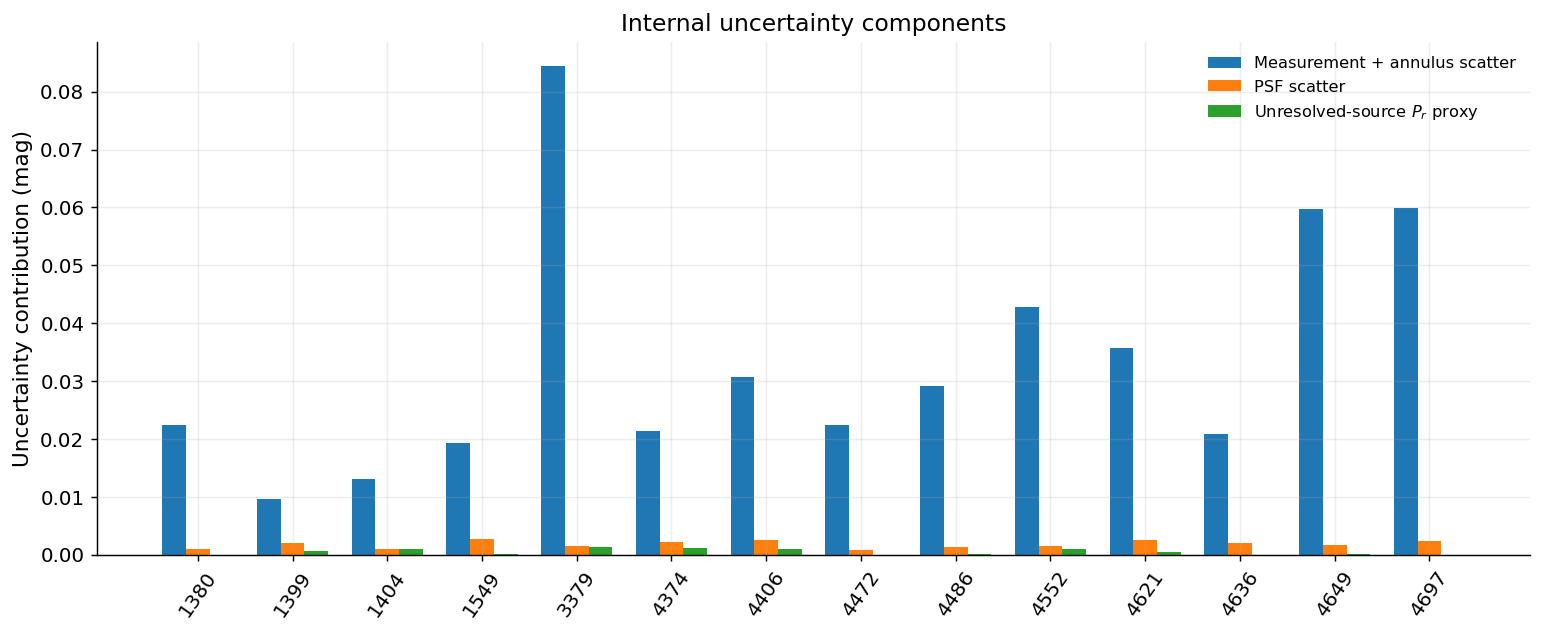

In [13]:
ordered = master.sort_values('galaxy').reset_index(drop=True)
x = np.arange(len(ordered))
labels = ordered['galaxy'].str.replace('NGC ', '')

fig, axes = plt.subplots(3, 1, figsize=(12.5, 10.0), sharex=True)

axes[0].plot(x, ordered['inner_usable_fraction'], 'o-', label='Inner usable fraction')
axes[0].plot(x, ordered['outer_usable_fraction'], 's-', label='Outer usable fraction')
axes[0].plot(x, ordered['inner_model_coverage'], 'o--', alpha=0.75, label='Inner model coverage')
axes[0].plot(x, ordered['outer_model_coverage'], 's--', alpha=0.75, label='Outer model coverage')
axes[0].axhline(0.70, color='#dc2626', lw=1.0, ls=':')
axes[0].set_ylabel('Fraction')
axes[0].set_ylim(0, 1.05)
axes[0].legend(ncol=2, frameon=False)

axes[1].axhline(0, color='black', lw=1.0)
axes[1].bar(x, ordered['annulus_delta_mag'], color='#7c3aed', alpha=0.78)
axes[1].axhline(0.10, color='#dc2626', lw=1.0, ls=':')
axes[1].axhline(-0.10, color='#dc2626', lw=1.0, ls=':')
axes[1].set_ylabel(r'$\overline{m}_{outer}-\overline{m}_{inner}$ (mag)')

width = 0.38
axes[2].bar(x - width/2, ordered['inner_P1'], width, label='Inner $P_1$')
axes[2].bar(x + width/2, ordered['outer_P1'], width, label='Outer $P_1$')
axes[2].axhline(0, color='black', lw=1.0)
axes[2].set_ylabel(r'$P_1$')
axes[2].set_xticks(x, labels, rotation=55)
axes[2].legend(frameon=False)

fig.suptitle('GO-3055 measurement diagnostics', y=1.01)
fig.tight_layout()
save_figure(fig, 'go3055_measurement_diagnostics')
plt.show()

fig, ax = plt.subplots(figsize=(12.0, 5.0))
width = 0.25
ax.bar(x - width, ordered['sigma_measurement_mag'], width, label='Measurement + annulus scatter')
ax.bar(x, ordered['sigma_psf_mag'], width, label='PSF scatter')
ax.bar(x + width, ordered['sigma_Pr_mag'], width, label=r'Unresolved-source $P_r$ proxy')
ax.set_xticks(x, labels, rotation=55)
ax.set_ylabel('Uncertainty contribution (mag)')
ax.set_title('Internal uncertainty components')
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, 'go3055_internal_error_budget')
plt.show()

## 12. Проверка двух ступенек Virgo–Fornax

На подвыборке Virgo+Fornax сравниваются общая линия и модель с добавочной константой $\Delta_{\rm Fornax}$. Это поисковая проверка: в Fornax только три галактики, поэтому вывод должен опираться на величину сдвига, bootstrap-интервал и разность AICc, а не на один красивый график.

,n,intercept,slope,delta_fornax,sigma_int,log_likelihood,aic,aicc,delta_fornax_p16,delta_fornax_p50,delta_fornax_p84,aicc_no_step,delta_aicc_step_minus_no_step,bootstrap_success
0,12,-3.1312,-0.1663,-0.1249,0.0573,14.6756,-21.3512,-15.6369,-0.2088,-0.1397,-0.0652,-16.5456,0.9086,1945


Сохранено: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures/go3055_virgo_fornax_step.png


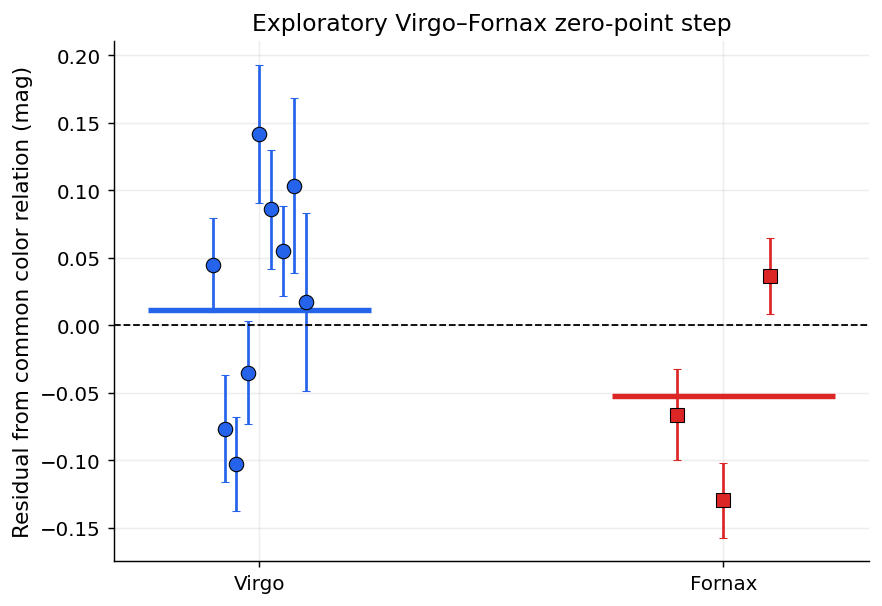

In [14]:
def fit_cluster_step(frame, color_center=common_color_center):
    data = frame.dropna(subset=['color_F090W_F150W', 'Mbar_F150W', 'sigma_Mbar_internal']).copy()
    x = data['color_F090W_F150W'].to_numpy(float)
    y = data['Mbar_F150W'].to_numpy(float)
    sy = data['sigma_Mbar_internal'].to_numpy(float)
    fornax = data['environment'].eq('Fornax').to_numpy(float)
    if fornax.min() == fornax.max():
        raise ValueError('Нужны объекты и Virgo, и Fornax')

    base = fit_calibration(data, color_center=color_center)

    def negative_log_likelihood(theta):
        intercept, slope, delta_fornax, log_sigma_int = theta
        sigma_int = np.exp(log_sigma_int)
        model = intercept + slope * (x - color_center) + delta_fornax * fornax
        variance = sy**2 + sigma_int**2
        return 0.5 * np.sum(np.log(2 * np.pi * variance) + (y - model)**2 / variance)

    solution = minimize(
        negative_log_likelihood,
        x0=[base['intercept'], base['slope'], 0.0, np.log(max(base['sigma_int'], 1e-4))],
        method='L-BFGS-B',
        bounds=[(None, None), (None, None), (None, None), (np.log(1e-5), np.log(1.0))],
    )
    if not solution.success:
        raise RuntimeError(solution.message)
    intercept, slope, delta_fornax, log_sigma_int = solution.x
    n, k = len(data), 4
    aic = 2 * k + 2 * solution.fun
    aicc = aic + 2 * k * (k + 1) / (n - k - 1) if n > k + 1 else np.inf
    return {
        'n': n, 'intercept': float(intercept), 'slope': float(slope),
        'delta_fornax': float(delta_fornax), 'sigma_int': float(np.exp(log_sigma_int)),
        'log_likelihood': float(-solution.fun), 'aic': float(aic), 'aicc': float(aicc),
    }

virgo_fornax = sample_all[sample_all['environment'].isin(['Virgo', 'Fornax'])].copy()
fit_no_step = fit_calibration(virgo_fornax, color_center=common_color_center)
fit_step = fit_cluster_step(virgo_fornax)

rng = np.random.default_rng(RNG_SEED + 2)
step_bootstrap_rows = []
for _ in range(N_BOOTSTRAP):
    sample = virgo_fornax.iloc[rng.integers(0, len(virgo_fornax), len(virgo_fornax))]
    if sample['environment'].nunique() < 2 or sample['color_F090W_F150W'].nunique() < 2:
        continue
    try:
        step_bootstrap_rows.append(fit_cluster_step(sample))
    except (ValueError, RuntimeError, np.linalg.LinAlgError):
        continue
step_bootstrap = pd.DataFrame(step_bootstrap_rows)

step_summary = pd.DataFrame([{
    **fit_step,
    'delta_fornax_p16': step_bootstrap['delta_fornax'].quantile(0.16),
    'delta_fornax_p50': step_bootstrap['delta_fornax'].quantile(0.50),
    'delta_fornax_p84': step_bootstrap['delta_fornax'].quantile(0.84),
    'aicc_no_step': fit_no_step['aicc'],
    'delta_aicc_step_minus_no_step': fit_step['aicc'] - fit_no_step['aicc'],
    'bootstrap_success': len(step_bootstrap),
}])
step_summary.to_csv(TABLE_DIR / 'go3055_virgo_fornax_step_test.csv', index=False)
display(step_summary)

base_prediction = fit_no_step['intercept'] + fit_no_step['slope'] * (
    virgo_fornax['color_F090W_F150W'] - common_color_center
)
virgo_fornax['residual_no_step'] = virgo_fornax['Mbar_F150W'] - base_prediction

fig, ax = plt.subplots(figsize=(7.5, 5.2))
for environment, group in virgo_fornax.groupby('environment'):
    xpos = 0 if environment == 'Virgo' else 1
    jitter = np.linspace(-0.10, 0.10, len(group)) if len(group) > 1 else np.array([0.0])
    ax.errorbar(
        xpos + jitter, group['residual_no_step'], yerr=group['sigma_Mbar_internal'],
        fmt=ENVIRONMENT_STYLE[environment]['marker'], ms=8,
        color=environment_colors[environment], mec='black', mew=0.6, capsize=2,
    )
    mean = np.average(group['residual_no_step'], weights=1 / group['sigma_Mbar_internal']**2)
    ax.hlines(mean, xpos - 0.24, xpos + 0.24, color=environment_colors[environment], lw=3)
ax.axhline(0, color='black', lw=1.0, ls='--')
ax.set_xticks([0, 1], ['Virgo', 'Fornax'])
ax.set_ylabel('Residual from common color relation (mag)')
ax.set_title('Exploratory Virgo–Fornax zero-point step')
save_figure(fig, 'go3055_virgo_fornax_step')
plt.show()

## 13. Необязательный лист визуального контроля

Если `MAKE_CONTACT_SHEET = True`, строится чёрно-белая таблица из гладкой модели, остатков до удаления компактных источников и рабочих остатков после маскирования. По умолчанию выключено, потому что чтение всех FITS занимает время и такой рисунок нужен для диагностики, а не для калибровки.

In [15]:
def read_central_crop(path, half_size=650, stride=4):
    with fits.open(Path(path), memmap=True) as hdul:
        data = hdul[0].data
        header = hdul[0].header
        ny, nx = data.shape
        x0 = int(round(float(header.get('SBFXCEN', (nx - 1) / 2))))
        y0 = int(round(float(header.get('SBFYCEN', (ny - 1) / 2))))
        x1, x2 = max(0, x0 - half_size), min(nx, x0 + half_size)
        y1, y2 = max(0, y0 - half_size), min(ny, y0 + half_size)
        return np.asarray(data[y1:y2:stride, x1:x2:stride], dtype=float)

if MAKE_CONTACT_SHEET:
    columns = [
        ('model_full_fits', 'Smooth model'),
        ('science_residual_pre_catalog_fits', 'Before compact-source mask'),
        ('science_residual_fits', 'Working residual'),
    ]
    ordered = master.sort_values('galaxy')
    fig, axes = plt.subplots(len(ordered), len(columns), figsize=(10.5, 3.0 * len(ordered)))
    for row_index, (_, row) in enumerate(ordered.iterrows()):
        for column_index, (path_column, title) in enumerate(columns):
            image = read_central_crop(row[path_column])
            finite = image[np.isfinite(image)]
            ax = axes[row_index, column_index]
            if path_column == 'model_full_fits':
                vmin, vmax = np.nanpercentile(finite, [2, 99.5])
            else:
                scale = np.nanpercentile(np.abs(finite), 99.3)
                vmin, vmax = -scale, scale
            ax.imshow(image, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
            if row_index == 0:
                ax.set_title(title)
            if column_index == 0:
                ax.set_ylabel(row['galaxy'])
    fig.tight_layout()
    save_figure(fig, 'go3055_diagnostic_contact_sheet')
    plt.show()
else:
    print('Лист визуального контроля выключен. Установите MAKE_CONTACT_SHEET = True в настройках.')

Лист визуального контроля выключен. Установите MAKE_CONTACT_SHEET = True в настройках.


## 14. Краткий итог текущего запуска

Последняя ячейка печатает числа, которые удобно переносить в рабочий отчёт. Окончательные формулировки для статьи следует делать только после заполнения ошибок неба и поглощения и после решения, остаются ли объекты со структурными предупреждениями в основной выборке.

In [16]:
delta = loo['delta_mu_sbf_minus_trgb']
print(f'Успешно обработано: {len(master)}/14')
print(f'Основная калибровочная выборка: {int(master.include_main.sum())}')
print(f'Без структурных предупреждений: {int(master.include_structural_clean.sum())}')
print(f'Virgo / Fornax / Other: {master.environment.value_counts().to_dict()}')
print()
print(f"Калибровка всей выборки при C0={common_color_center:.4f}:")
print(f"  a = {fit_all['intercept']:.4f} mag")
print(f"  b = {fit_all['slope']:.4f}")
print(f"  sigma_int = {fit_all['sigma_int']:.4f} mag")
print()
print('Leave-one-out расстояния:')
print(f'  средний остаток SBF−TRGB = {delta.mean():+.4f} mag')
print(f'  RMS = {np.sqrt(np.mean(delta**2)):.4f} mag')
print(f'  медиана |остатка| = {np.median(np.abs(delta)):.4f} mag')
print()
print('Virgo–Fornax:')
print(f"  Delta_Fornax = {fit_step['delta_fornax']:+.4f} mag")
print(f"  Delta AICc (step - no step) = {fit_step['aicc'] - fit_no_step['aicc']:+.2f}")
print()
print(f'Все таблицы: {TABLE_DIR}')
print(f'Все рисунки: {FIGURE_DIR}')

Успешно обработано: 14/14
Основная калибровочная выборка: 14
Без структурных предупреждений: 9
Virgo / Fornax / Other: {'Virgo': 9, 'Fornax': 3, 'Other': 2}

Калибровка всей выборки при C0=0.5908:
  a = -3.1696 mag
  b = 0.7136
  sigma_int = 0.0716 mag

Leave-one-out расстояния:
  средний остаток SBF−TRGB = +0.0076 mag
  RMS = 0.1006 mag
  медиана |остатка| = 0.0919 mag

Virgo–Fornax:
  Delta_Fornax = -0.1249 mag
  Delta AICc (step - no step) = +0.91

Все таблицы: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/tables
Все рисунки: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/runs/sbf2_go3055/analysis/figures
